### PCA Dimensionality Reduction

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("../../data/preprocessed/preprocessed_dataset.csv")

X = data.drop(columns=["class", "subject", "expression"])
y = data["expression"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

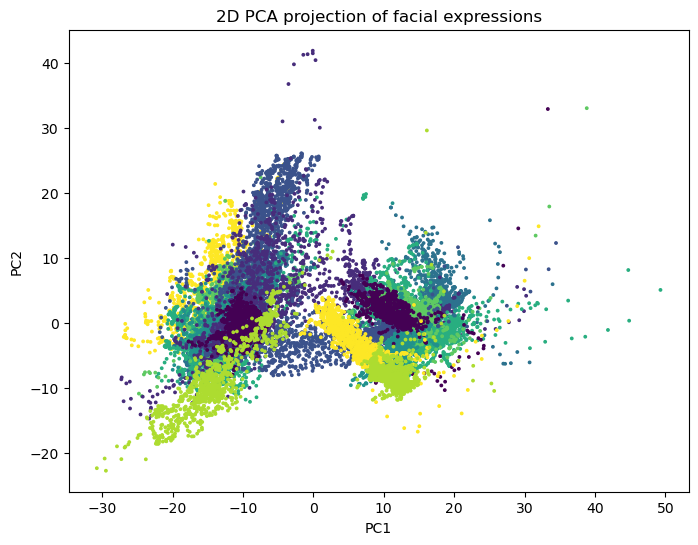

In [2]:
# 2D PCA vizuelizacija
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca2[:,0],
    X_pca2[:,1],
    c=data["expression"].astype("category").cat.codes,
    s=3
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA projection of facial expressions")
plt.show()

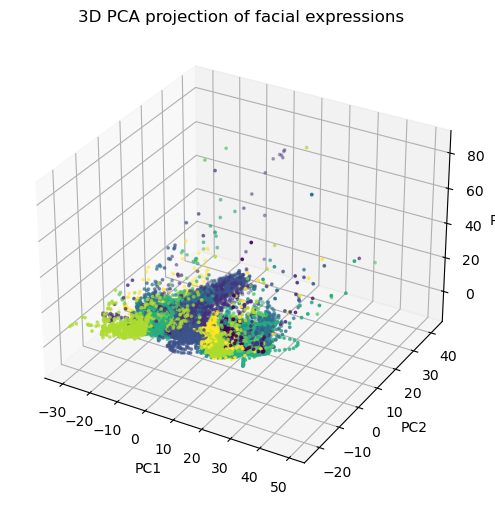

In [3]:
# 3D PCA vizuelizacija
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=data["expression"].astype("category").cat.codes,
    s=3
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D PCA projection of facial expressions")
plt.show()

##### Explained Variance

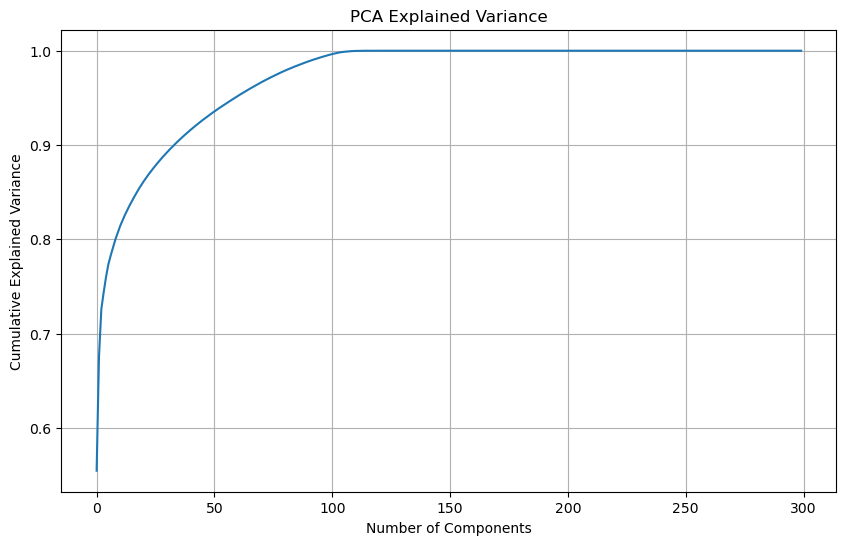

In [4]:
pcaFull = PCA()
pcaFull.fit(X_scaled)

explained_variance = np.cumsum(pcaFull.explained_variance_ratio_)

plt.figure(figsize=(10,6))
plt.plot(explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [5]:
# Hocemo da nadjemo indeks od kog je explained_variance >= 0.95 -> toliko komponenti nam treba da objasnimo 95% varijanse
nComponents = np.argmax(explained_variance >= 0.95) + 1
print("Components for 95% variance: ", nComponents)

Components for 95% variance:  60


In [6]:
X_pca = PCA(n_components=nComponents)
X_pca = X_pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

print("\nSaving...")
# Čuvanje rezultata u .npy formatu jer su manji, brže se učitavaju i efikasniji su za rad sa modelima 
# bez potrebe za ponovnim skaliranjem ili PCA transformacijom, tj. bez parsiranja CSV fajla i ponovnog izvođenja svih koraka preprocesiranja.
np.save("../../data/reduced/X_scaled.npy", X_scaled)
print("Scaled data saved to X_scaled.npy")
np.save("../../data/reduced/X_pca.npy", X_pca)
print("PCA data saved to X_pca.npy")
print("Done!")

Original shape: (27936, 300)
Scaled shape: (27936, 300)
PCA shape: (27936, 60)

Saving...
Scaled data saved to X_scaled.npy
PCA data saved to X_pca.npy
Done!
